In [2]:
# make sure to choose the python_course environment

# import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = df[df['job_title_short'] == "Data Analyst"]

In [4]:
def clean_list(skill_list):
    if pd.notna(skill_list): # notna is calling out not NaN values, i.e. values we want
        return ast.literal_eval(skill_list)

df['job_skills'] = df['job_skills'].apply(clean_list)

In [5]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

In [6]:
type(df['job_skills'].iloc[1])

list

In [7]:
skill_stats = skill_stats.sort_values('skill_count', ascending=False).head(20)

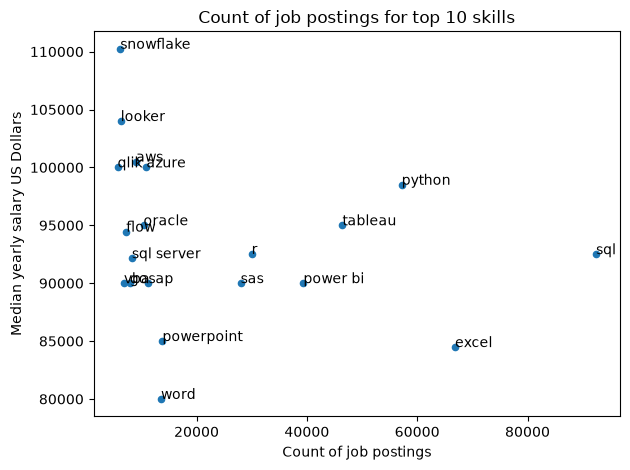

In [8]:
skill_stats.plot(kind='scatter', x='skill_count' , y='median_salary')
plt.xlabel("Count of job postings")
plt.ylabel('Median yearly salary US Dollars')
plt.title("Count of job postings for top 10 skills")
plt.tight_layout()


# matplotlib isn't good at making labels for datapoints, there's a workaround though ---> pyplot.text
# iterate through job skills with a for loop

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
    

plt.show()

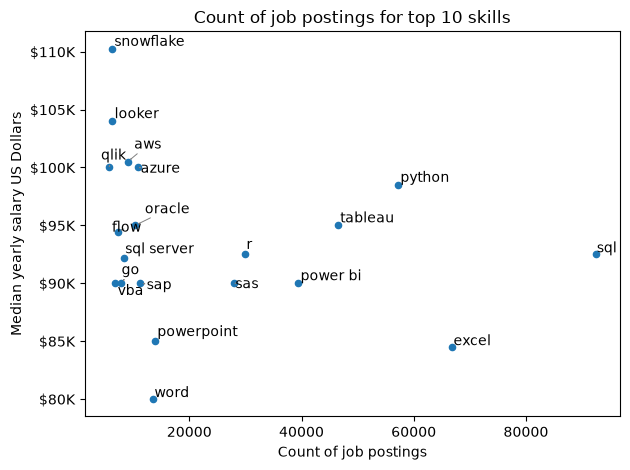

In [24]:
# we're going to use adjusttext to point arrows at datapoints to make it more readable
# we need to import this but it needs to be installed first

from adjustText import adjust_text



skill_stats.plot(kind='scatter', x='skill_count' , y='median_salary')
plt.xlabel("Count of job postings")
plt.ylabel('Median yearly salary US Dollars')
plt.title("Count of job postings for top 10 skills")
plt.tight_layout()


# matplotlib isn't good at making labels for datapoints, there's a workaround though ---> pyplot.text
# iterate through job skills with a for loop

texts=[] # the list here refers to the plt.text line below
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) # y was a float before, change the datatype

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=0.7))


plt.tight_layout()
plt.show()